In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


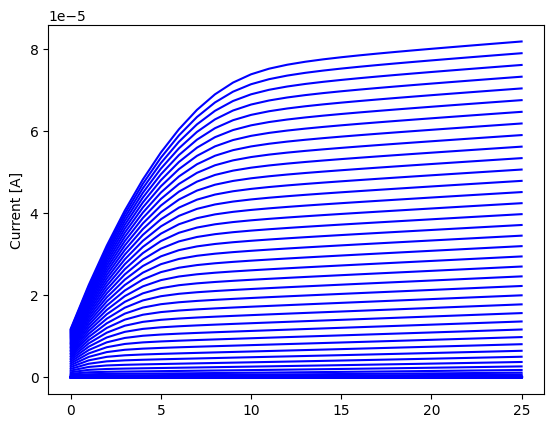

100%|██████████| 20000/20000 [10:43<00:00, 31.08it/s]


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import logging
from tqdm import tqdm
from src.get_first_device import get_first_device
from src.get_seperated_curves import get_seperated_curves
from src.plot_curves import plot_curves
from src.encoder import Encoder
from src.decoder import Decoder
from src.set_logger import set_logger
from src.get_reconstruction_loss import get_reconstruction_loss
from src.mlp import Mlp
from src.pretrain_latent_diffusion import pretrain_latent_diffusion
from src.visualize_0 import visualize_0
from src.get_20_devices import get_20_devices
from src.torch_dataset import TorchDataset

CSV_FILE = "nmos_130nm_gaussian_l_vth_rds_50_devs_into_subth.csv"
SEP = " "
DEVICE_DIM = 1378
CURRENT_COL = 3
VOLTAGE_0_DIM = 53
VOLTAGE_1_DIM = 26
LEARNING_RATE = 2e-4
EPOCHS = 20_000
LOGGING_FILE = "logs.log"
LOGGER_LEVEL = logging.INFO

dataframe = pd.read_csv(CSV_FILE, sep=SEP, header=None)
logger = set_logger(LOGGING_FILE, LOGGER_LEVEL)
torch_dataset = TorchDataset(
    dataframe,
    CURRENT_COL,
    DEVICE_DIM
)
train_loader = torch.utils.data.DataLoader(
    torch_dataset, batch_size=5
)

first_device_data = get_first_device(dataframe, DEVICE_DIM, CURRENT_COL)
separated_curves = get_seperated_curves(first_device_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
device = "cuda"

encoder = Encoder().to(device)
decoder = Decoder().to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE
)

first_device_data_tensor = torch.tensor(first_device_data, dtype=torch.float32)
mse_loss = torch.nn.MSELoss()

devices_20_data = get_20_devices(dataframe, DEVICE_DIM, CURRENT_COL) 
devices_20_data_tensor = torch.tensor(devices_20_data, dtype=torch.float32)

loss_list = []
for epoch in tqdm(range(EPOCHS)):
    train_loader_iter = iter(train_loader)
    for batch_index, dev_data in enumerate(train_loader):
    # for dev in devices_20_data_tensor:
        device_data = dev_data.to(torch.float32)
        device_data = device_data.to(device)
        latent_data = encoder(device_data)
        output_data = decoder(latent_data)

        loss = get_reconstruction_loss(output_data, device_data)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss_list.append(loss.item())

    if epoch % 1000 == 0:
        plt.plot(loss_list[-1000:])
        plt.title(f"Epoch {epoch}")
        plt.savefig(f"loss_epoch{epoch}.png")
        plt.close()
    
    if epoch % 100 == 0:
        logger.info(f"EPOCH: {epoch} LOSS: {loss.item()}")

In [15]:
feature_0_list = []
feature_10_list = []

samples_list = []
for i in range(50):
    samples_list.append([])

for i in range(len(torch_dataset)):
    features_vector_np = torch_dataset[i]
    features_vector_tensor = torch.tensor(features_vector_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        latent_tensor = encoder(features_vector_tensor)
    latent_numpy =  latent_tensor.cpu().numpy()

    for index in range(len(latent_numpy)):
        samples_list[index].append(latent_numpy[index])

# plt.plot(feature_0_list)
# plt.show()
# plt.plot(feature_10_list)
var_list = []
mean_list = []

var_0_count = 0

for i in range(len(samples_list)):
    var_val = np.var(samples_list[i])
    var_list.append(var_val)
    mean_list.append(np.mean(samples_list[i]))

    if np.isclose(var_val, 0.0):
        var_0_count += 1

for i in range(len(samples_list)):
    print(var_list[i])

0.0
0.054671
0.05578648
0.06109469
0.0
0.058332562
0.0
2.9597459e-05
0.06133831
0.0
0.0
0.0
0.0
0.040202945
0.0
0.053657964
0.0005368068
0.059916843
0.0
0.056481786
0.0577316
0.06161782
0.0006531551
0.0
0.06063463
0.0
0.0
0.0
0.051385883
0.0
0.0
0.0010556544
0.06534449
0.057233244
0.04778792
0.0
0.0
0.060251027
0.06193042
0.04580153
0.05612636
0.05511779
0.0
0.054842383
0.057660583
0.058524065
0.055985693
0.00056601496
0.0
0.0


In [16]:
for i in range(len(samples_list)):
    print(mean_list[i])

0.0
0.18565778
0.18482126
0.1778155
0.0
0.183171
0.0
0.0011997219
0.18614633
0.0
0.0
0.0
0.0
0.1506797
0.0
0.17488535
0.0048148017
0.18130451
0.0
0.18835926
0.18432255
0.1998123
0.0066829766
0.0
0.18696623
0.0
0.0
0.0
0.18809319
0.0
0.0
0.0046415483
0.18655898
0.19299063
0.17409903
0.0
0.0
0.1916972
0.18701683
0.1536182
0.18930826
0.17565405
0.0
0.1777316
0.19085994
0.18566383
0.19314682
0.0065069133
0.0
0.0


In [17]:
var_0_count

20

In [18]:
for i in range(len(samples_list)):
    print(f"VAR: {var_list[i]}  MEAN: {mean_list[i]}")

VAR: 0.0  MEAN: 0.0
VAR: 0.05467100068926811  MEAN: 0.1856577843427658
VAR: 0.05578647926449776  MEAN: 0.1848212629556656
VAR: 0.06109469011425972  MEAN: 0.1778154969215393
VAR: 0.0  MEAN: 0.0
VAR: 0.05833256244659424  MEAN: 0.18317100405693054
VAR: 0.0  MEAN: 0.0
VAR: 2.959745870612096e-05  MEAN: 0.001199721940793097
VAR: 0.061338309198617935  MEAN: 0.1861463338136673
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.040202945470809937  MEAN: 0.15067969262599945
VAR: 0.0  MEAN: 0.0
VAR: 0.05365796387195587  MEAN: 0.1748853474855423
VAR: 0.000536806823220104  MEAN: 0.00481480173766613
VAR: 0.059916842728853226  MEAN: 0.18130451440811157
VAR: 0.0  MEAN: 0.0
VAR: 0.05648178607225418  MEAN: 0.18835926055908203
VAR: 0.05773159861564636  MEAN: 0.1843225508928299
VAR: 0.06161782145500183  MEAN: 0.19981229305267334
VAR: 0.0006531550898216665  MEAN: 0.0066829766146838665
VAR: 0.0  MEAN: 0.0
VAR: 0.06063463166356087  MEAN: 0.18696622550487518
VAR: 0.0  MEAN:

tensor([1.9893e-12, 3.4617e-12, 9.0675e-12,  ..., 7.6184e-05, 7.9046e-05,
        8.1907e-05], device='cuda:0')


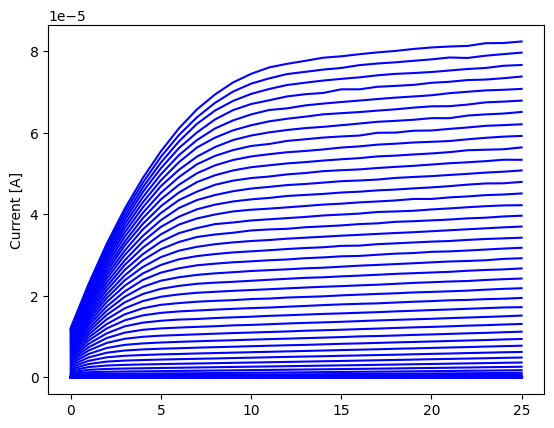

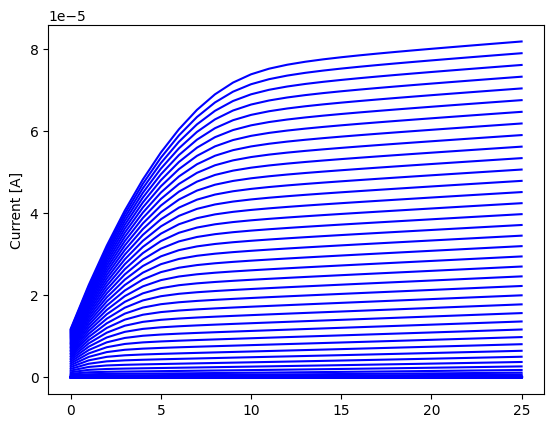

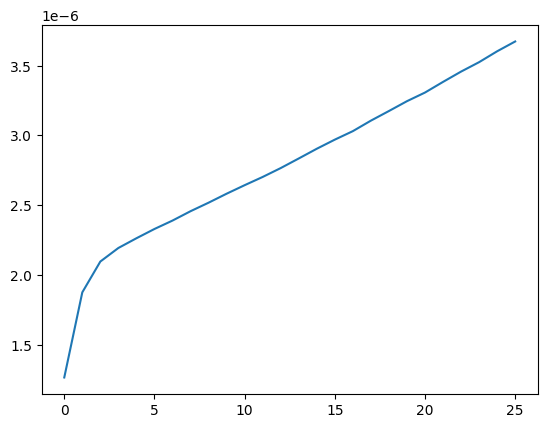

8.2356855e-05


In [20]:
encoder.eval()
decoder.eval()

data_for_encoder = torch_dataset[0]
data_for_encoder = torch.tensor(data_for_encoder, dtype=torch.float32)
data_for_encoder = data_for_encoder.to(device)
# data_for_encoder = torch.zeros_like(data_for_encoder, dtype=torch.float32)
print(data_for_encoder)

with torch.no_grad():
    encoded_data = encoder(data_for_encoder)
    decoded_data = decoder(encoded_data)

decoded_data = decoded_data.cpu().numpy()
separated_curves = get_seperated_curves(decoded_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
separated_curves_1 = get_seperated_curves(data_for_encoder.cpu().numpy(), VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves_1)

plt.plot(separated_curves[20])
plt.show()
print(np.max(decoded_data))

In [11]:
# torch.save(encoder, "encoder_full_model.pth")
# torch.save(decoder, "decoder_full_model.pth")

In [ ]:
TIMESTEPS = 40
EPOCHS = 300_000
mlp_model = Mlp(TIMESTEPS)
diffusion_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=LEARNING_RATE
)
betas = (torch.sigmoid(torch.linspace(-18, 10, TIMESTEPS)) * (3e-1 - 1e-5) + 1e-5)
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

pretrain_latent_diffusion(mlp_model, encoder, first_device_data_tensor, diffusion_optimizer, EPOCHS, betas, alphas, alphas_bar, TIMESTEPS, logger)

In [ ]:
out_tensor = visualize_0(
    first_device_data_tensor,
    alphas_bar,
    betas,
    alphas,
    TIMESTEPS,
    mlp_model,
    encoder,
    decoder
)

out_numpy_data = out_tensor.numpy()

separated_curves = get_seperated_curves(out_numpy_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)